In [113]:
import numpy as np
import pandas as pd


In [114]:
df = pd.read_csv(r"C:\Users\SIDDHARTH\OneDrive\Documents\Job profiles\Code_notes\Deep Learning\Churn_Modelling.csv")

In [115]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Feature extraction and scaling 

In [116]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [117]:
df.duplicated().sum()

0

In [118]:
df['Surname'].value_counts()

Surname
Smith       32
Scott       29
Martin      29
Walker      28
Brown       26
            ..
Izmailov     1
Bold         1
Bonham       1
Poninski     1
Burbidge     1
Name: count, Length: 2932, dtype: int64

In [119]:
df['Surname'].nunique()

2932

In [120]:
df.drop(columns= ['Surname','RowNumber','CustomerId'], inplace= True)

In [121]:
df = pd.get_dummies(df,columns=['Geography','Gender'], drop_first= True, dtype= int)

In [122]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [123]:
df['CreditScore'].min()

350

In [124]:
df['CreditScore'].max()

850

In [125]:
import matplotlib.pyplot as plt


In [126]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [127]:
x = df.drop(columns= ['Exited'])
y = df['Exited']

from sklearn.model_selection  import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size= 0.2)

In [128]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [129]:
x_train_scaled

array([[-1.99493749, -0.37111219,  0.00480634, ..., -0.57735027,
         1.73842505, -1.08976394],
       [ 1.09719052,  0.00904051,  0.00480634, ...,  1.73205081,
        -0.57523331, -1.08976394],
       [ 1.25283455,  0.19911686,  1.73682086, ..., -0.57735027,
        -0.57523331, -1.08976394],
       ...,
       [-0.02344648, -1.22645577,  1.39041796, ..., -0.57735027,
        -0.57523331,  0.91762992],
       [ 1.40847857, -0.46615037, -0.68799947, ..., -0.57735027,
        -0.57523331,  0.91762992],
       [ 1.47073619,  2.95522394, -0.68799947, ..., -0.57735027,
        -0.57523331, -1.08976394]])

## Training the model


In [130]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [165]:
model = Sequential()

model.add(Dense(11,activation= 'relu', input_dim = 11))
model.add(Dense(11,activation= 'relu'))
model.add(Dense(3,activation= 'relu'))
model.add(Dense(1,activation='relu'))

c:\Users\SIDDHARTH\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [132]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 304 (1.19 KB)

 Trainable params: 304 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

In [166]:
model.compile(loss = 'binary_crossentropy',optimizer='Adam')

In [167]:
model.fit(x_train_scaled,y_train,epochs= 50)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 523us/step - loss: 3.1882
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 545us/step - loss: 3.1933
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step - loss: 2.4870
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step - loss: 0.5234
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 525us/step - loss: 0.4860
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 549us/step - loss: 0.4686
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step - loss: 0.4604
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 507us/step - loss: 0.4521
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 515us/step - loss: 0.4295
Epoch 10/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step - loss: 0.4307
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 521us/step - loss: 0.4191
Epoch 12/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - loss: 0.3956
Epoch 13/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step - loss: 0.3922
Epoch 14/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step - loss: 0.3878
Epoch 15/50
250/250 ━━━━━━━━━

In [168]:
y_predicted = model.predict(x_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step


## Finding Threshold for prediction

In [136]:
from sklearn.metrics import roc_curve


In [169]:
fpr, tpr , thresholds = roc_curve(y_test, y_predicted)


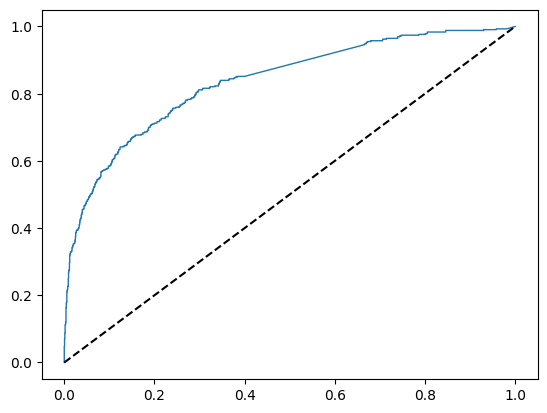

In [170]:
plt.plot(fpr, tpr, linewidth=1)
plt.plot([0, 1], [0, 1], 'k--') 
plt.show()

In [171]:
j_statistic = tpr - fpr
optimal_idx = np.argmax(j_statistic)
optimal_threshold = thresholds[optimal_idx]

In [180]:
optimal_threshold

0.27626878

In [177]:
y_result = np.where(y_predicted > 0.6, 1, 0)

In [142]:
y_predicted

array([[0.06993517],
       [0.039904  ],
       [1.1962905 ],
       ...,
       [0.13864522],
       [0.02647444],
       [0.02647444]], dtype=float32)

## Finding accuracy for the model


In [178]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_result)

0.85